# Phase 4 — Unseen-Test Evaluation
All metrics below are computed from actual model outputs on the untouched test split.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
import torch, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

## Load the unseen test set
The test split is read from the Phase 2 manifest without resampling or augmentation.

In [2]:
root = Path.cwd(); df = pd.read_csv(root / 'phase2_clean_splits.csv'); df = df[df.split.eq('test')].reset_index(drop=True)
df['target'] = df.label.map({'OK':0, 'Defective':1})
tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize([.485,.456,.406],[.229,.224,.225])])
class TestDS(Dataset):
    def __len__(self): return len(df)
    def __getitem__(self,i): return tf(Image.open(df.iloc[i].path).convert('RGB')), int(df.iloc[i].target)
loader = DataLoader(TestDS(), batch_size=64, shuffle=False); print(f'Unseen test images: {len(df):,}')

Unseen test images: 1,093


## Load the trained baseline
The checkpoint is the Phase 3 pretrained MobileNetV2 head baseline.

In [3]:
model = models.mobilenet_v2(weights=None); model.classifier[1] = torch.nn.Linear(model.last_channel, 2)
model.load_state_dict(torch.load(root / 'phase3_mobilenetv2_head_baseline.pt', map_location='cpu')); model.eval()
truth, pred, scores, paths = [], [], [], []
with torch.no_grad():
    for x,y in loader: out = model(x); truth += y.tolist(); pred += out.argmax(1).tolist(); scores += out.softmax(1)[:,1].tolist()
paths = df.path.tolist(); print('Inference complete.')

Inference complete.


## Calculate classification metrics
ROC-AUC is computed from the continuous Defective probability scores.

In [4]:
accuracy = accuracy_score(truth, pred); precision, recall, f1, _ = precision_recall_fscore_support(truth,pred,average='binary',zero_division=0)
auc = roc_auc_score(truth, scores); cm = confusion_matrix(truth, pred)
report = classification_report(truth,pred,target_names=['OK','Defective'],digits=4,output_dict=True)
metrics = {'accuracy':accuracy,'precision':precision,'recall':recall,'f1':f1,'roc_auc':auc,'confusion_matrix':cm.tolist(),'classification_report':report}
print(json.dumps({k:v for k,v in metrics.items() if k != 'classification_report'}, indent=2)); print(classification_report(truth,pred,target_names=['OK','Defective'],digits=4))

{
  "accuracy": 0.9405306495882891,
  "precision": 0.9930434782608696,
  "recall": 0.9034810126582279,
  "f1": 0.9461474730737366,
  "roc_auc": 0.9935027046321975,
  "confusion_matrix": [
    [
      457,
      4
    ],
    [
      61,
      571
    ]
  ]
}
              precision    recall  f1-score   support

          OK     0.8822    0.9913    0.9336       461
   Defective     0.9930    0.9035    0.9461       632

    accuracy                         0.9405      1093
   macro avg     0.9376    0.9474    0.9399      1093
weighted avg     0.9463    0.9405    0.9409      1093



## Plot confusion matrix and ROC curve
Both figures are derived from the same unseen-test predictions.

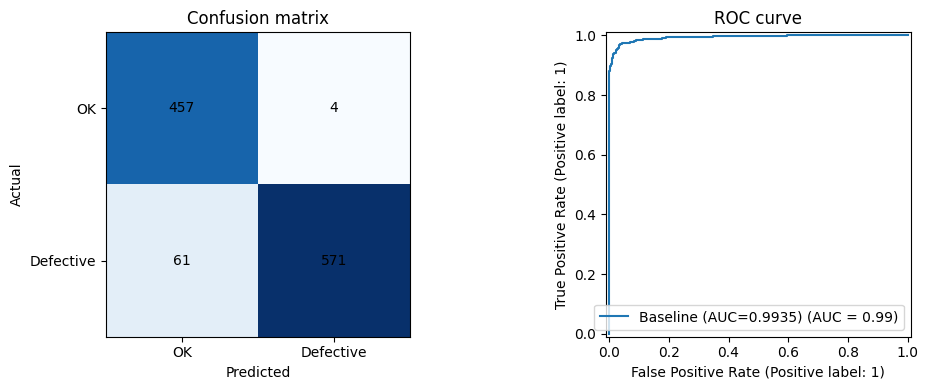

In [5]:
fig, ax = plt.subplots(1,2,figsize=(11,4)); ax[0].imshow(cm,cmap='Blues')
ax[0].set(xticks=[0,1],yticks=[0,1],xticklabels=['OK','Defective'],yticklabels=['OK','Defective'],xlabel='Predicted',ylabel='Actual',title='Confusion matrix')
for (i,j),v in np.ndenumerate(cm): ax[0].text(j,i,str(v),ha='center',va='center')
RocCurveDisplay.from_predictions(truth,scores,name=f'Baseline (AUC={auc:.4f})',ax=ax[1]); ax[1].set_title('ROC curve')
plt.tight_layout(); plt.savefig('phase4_complete_metrics.png',dpi=160); plt.show()

## Display correct predictions and failures
False positives and false negatives are selected directly from the test outputs.

Correct           1028
False negative      61
False positive       4
Name: case, dtype: int64


,path,label,case,defective_score
54,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.381947
65,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.484779
67,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.368446
70,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.452545
94,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.303770
...,...,...,...,...
1064,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.300507
1068,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.403731
1071,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.392564
1087,C:\Users\AbdElhalk\OneDrive\Desktop\computer v...,Defective,False negative,0.243631


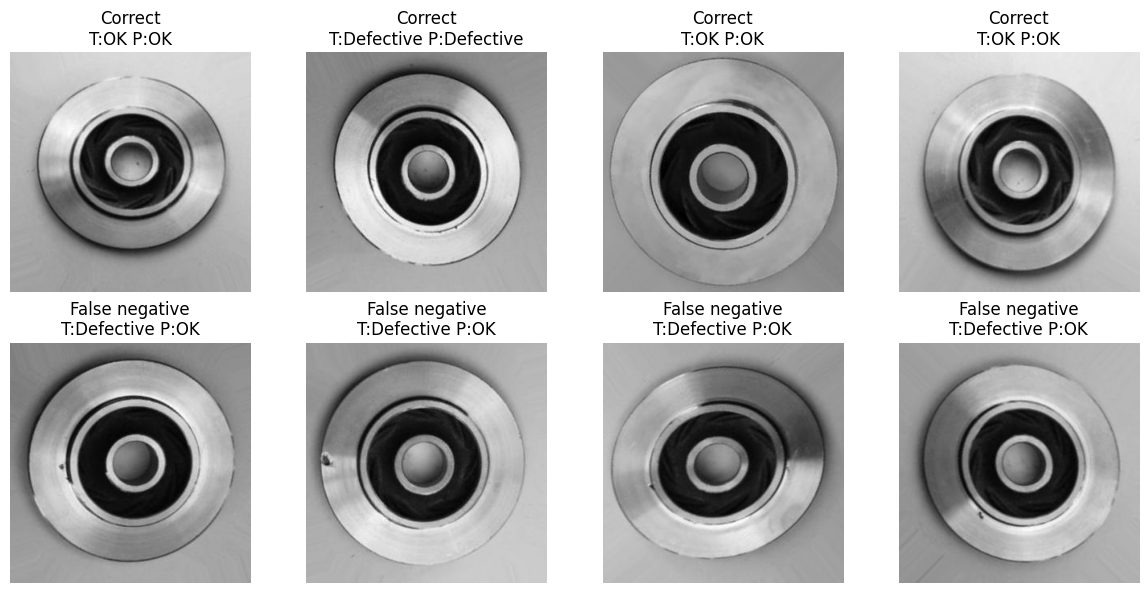

In [6]:
result = df.assign(actual=truth,predicted=pred,defective_score=scores)
result['case'] = np.where(result.actual.eq(result.predicted),'Correct',np.where((result.actual==0)&(result.predicted==1),'False positive','False negative'))
print(result.case.value_counts()); failures = result[result.case.ne('Correct')]; display(failures[['path','label','case','defective_score']])
show = pd.concat([result[result.case.eq('Correct')].head(4), failures.head(4)]).head(8)
fig, axes = plt.subplots(2,4,figsize=(12,6))
for ax,(_,r) in zip(axes.ravel(),show.iterrows()): ax.imshow(Image.open(r.path).convert('RGB')); ax.set_title(f"{r.case}\nT:{r.label} P:{'Defective' if r.predicted else 'OK'}"); ax.axis('off')
plt.tight_layout(); plt.savefig('phase4_correct_and_failures.png',dpi=160); plt.show()

## Save the evaluation artifacts
The report, per-image predictions, and figures support Phase 5 analysis.

In [7]:
pd.DataFrame({'path':paths,'actual':truth,'predicted':pred,'defective_score':scores,'case':result.case}).to_csv('phase4_test_predictions.csv',index=False)
with open('phase4_complete_metrics.json','w') as f: json.dump(metrics,f,indent=2)
print('Saved metrics, classification report, predictions, and figures.')
print('Phase 4 complete; continuing to Phase 5.')

Saved metrics, classification report, predictions, and figures.
Phase 4 complete; continuing to Phase 5.
